In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
df = yf.download("AAPL", period="2y", interval="1d")
display(df)

#keep pnly close price
df = df[['Close']].dropna()

# important - no shuffle
train_size = int(len(df)*0.8)
train_df = df[:train_size]
test_df = df[train_size:]

/tmp/ipykernel_6423/1803056021.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-04-17,166.484848,169.110942,166.484848,168.080328,50901200
2024-04-18,165.533493,167.119069,165.047922,166.514570,43122900
2024-04-19,163.511902,164.899270,162.600201,164.710996,68149400
2024-04-22,164.344315,165.751506,163.283973,164.027208,48116400
2024-04-23,165.394760,165.543416,163.432622,163.858751,49537800
...,...,...,...,...,...
2026-04-10,260.480011,262.190002,259.019989,259.980011,31291500
2026-04-13,259.200012,260.179993,256.660004,259.730011,36234700


In [3]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

In [4]:
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [5]:
seq_length = 60
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

In [6]:
import torch
import torch.nn as nn


class LSTMModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True) #64 features are generated with each hidden_size
    self.dropout = nn.Dropout(0.2)
    self.fc = nn.Linear(64, 1)

  def forward(self, x):
    out, _ = self.lstm(x)
    out = self.dropout(out[:, -1, :])
    return self.fc(out)

model = LSTMModel()

In [7]:
import torch.optim as optim

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [8]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

In [9]:
for epoch in range(100):
  optimizer.zero_grad()
  y_pred = model(X_train_t)
  loss = loss_fn(y_pred, y_train_t)
  loss.backward()
  optimizer.step()

  if(epoch%10 == 0):
    print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.4651116728782654
Epoch 10, Loss: 0.09755989164113998
Epoch 20, Loss: 0.02777511440217495
Epoch 30, Loss: 0.0276822317391634
Epoch 40, Loss: 0.02460659295320511
Epoch 50, Loss: 0.0225832462310791
Epoch 60, Loss: 0.019100816920399666
Epoch 70, Loss: 0.010729924775660038
Epoch 80, Loss: 0.008972947485744953
Epoch 90, Loss: 0.008661922067403793


In [10]:
# eval modela and calculate predictions for testing data
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
  predictions = model(X_test_t).numpy()

In [11]:
# reshape for inverse transform

predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test)


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))
mae = mean_absolute_error(y_test_rescaled, predictions_rescaled)
# r2 = r2_score(y_test_rescaled, predictions_rescaled)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')


RMSE: 8.127640423248595
MAE: 6.626478986042304


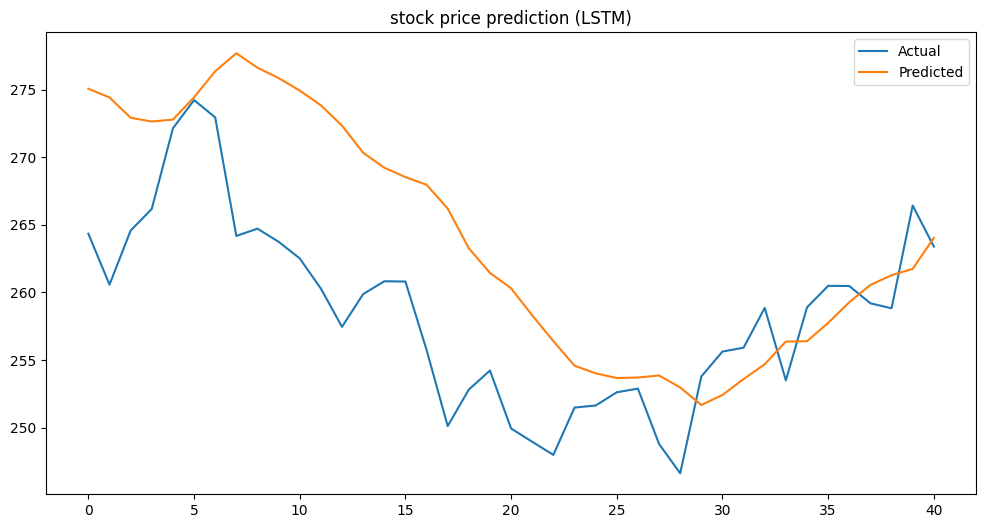

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(predictions_rescaled, label='Predicted')
plt.legend()
plt.title("stock price prediction (LSTM)")
plt.show()
#

In [15]:
#fine tune the above model on below two hyperparameters
# 1. number of neurons in hidden layer
# 2. Learning Rate(0.0001, 0.001, 0.01, 0.1 )


Epoch 0, Loss: 0.003633147105574608
Epoch 10, Loss: 0.0033696438185870647
Epoch 20, Loss: 0.0033082047011703253
Epoch 30, Loss: 0.003263274673372507
Epoch 40, Loss: 0.003223559120669961
Epoch 50, Loss: 0.0031838754657655954
Epoch 60, Loss: 0.003143197624012828
Epoch 70, Loss: 0.0031020143069326878
Epoch 80, Loss: 0.0030608377419412136
Epoch 90, Loss: 0.003019843017682433
RMSE: 5.778556825861412
MAE: 4.876180137076031


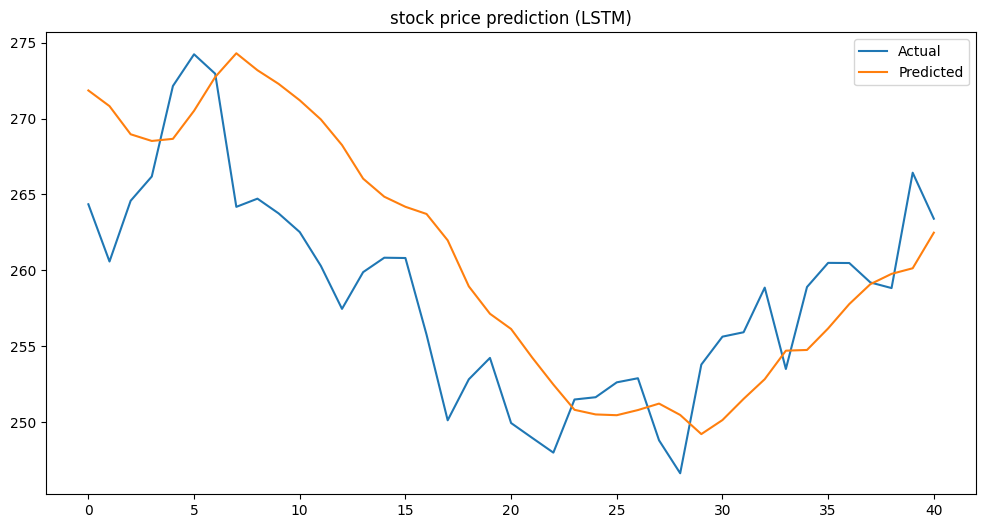

In [16]:
#1 Learning Rate(0.0001)
import torch.optim as optim

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
for epoch in range(100):
  optimizer.zero_grad()
  y_pred = model(X_train_t)
  loss = loss_fn(y_pred, y_train_t)
  loss.backward()
  optimizer.step()

  if(epoch%10 == 0):
    print(f'Epoch {epoch}, Loss: {loss.item()}')

# eval modela and calculate predictions for testing data

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
  predictions = model(X_test_t).numpy()

# reshape for inverse transform

predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))
mae = mean_absolute_error(y_test_rescaled, predictions_rescaled)
# r2 = r2_score(y_test_rescaled, predictions_rescaled)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(predictions_rescaled, label='Predicted')
plt.legend()
plt.title("stock price prediction (LSTM)")
plt.show()

Epoch 0, Loss: 0.0029791078995913267
Epoch 10, Loss: 0.003040496027097106
Epoch 20, Loss: 0.0027442218270152807
Epoch 30, Loss: 0.002599697792902589
Epoch 40, Loss: 0.0025044141802936792
Epoch 50, Loss: 0.0023936305660754442
Epoch 60, Loss: 0.0022938481997698545
Epoch 70, Loss: 0.0021959631703794003
Epoch 80, Loss: 0.002102089114487171
Epoch 90, Loss: 0.002020642627030611
RMSE: 4.149859375345321
MAE: 3.51351891494379


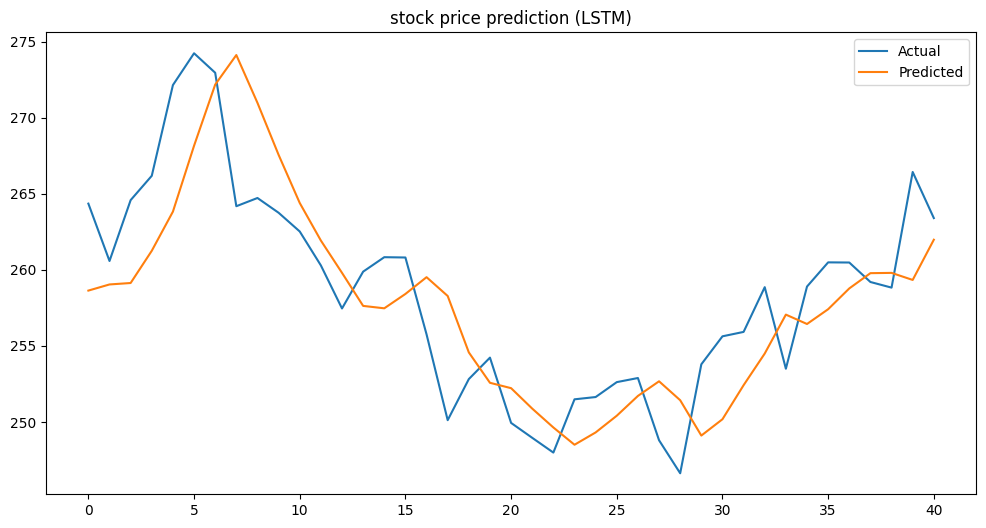

In [17]:
#1 Learning Rate(0.001)
import torch.optim as optim

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(100):
  optimizer.zero_grad()
  y_pred = model(X_train_t)
  loss = loss_fn(y_pred, y_train_t)
  loss.backward()
  optimizer.step()

  if(epoch%10 == 0):
    print(f'Epoch {epoch}, Loss: {loss.item()}')

# eval modela and calculate predictions for testing data

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
  predictions = model(X_test_t).numpy()

# reshape for inverse transform

predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))
mae = mean_absolute_error(y_test_rescaled, predictions_rescaled)
# r2 = r2_score(y_test_rescaled, predictions_rescaled)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(predictions_rescaled, label='Predicted')
plt.legend()
plt.title("stock price prediction (LSTM)")
plt.show()

Epoch 0, Loss: 0.0019396630814298987
Epoch 10, Loss: 0.005678909830749035
Epoch 20, Loss: 0.013206124305725098
Epoch 30, Loss: 0.007622872479259968
Epoch 40, Loss: 0.004133750218898058
Epoch 50, Loss: 0.002633207244798541
Epoch 60, Loss: 0.002232143422588706
Epoch 70, Loss: 0.001942263450473547
Epoch 80, Loss: 0.0018930594669654965
Epoch 90, Loss: 0.0018469025380909443
RMSE: 3.9044239048892226
MAE: 3.1665705238900554


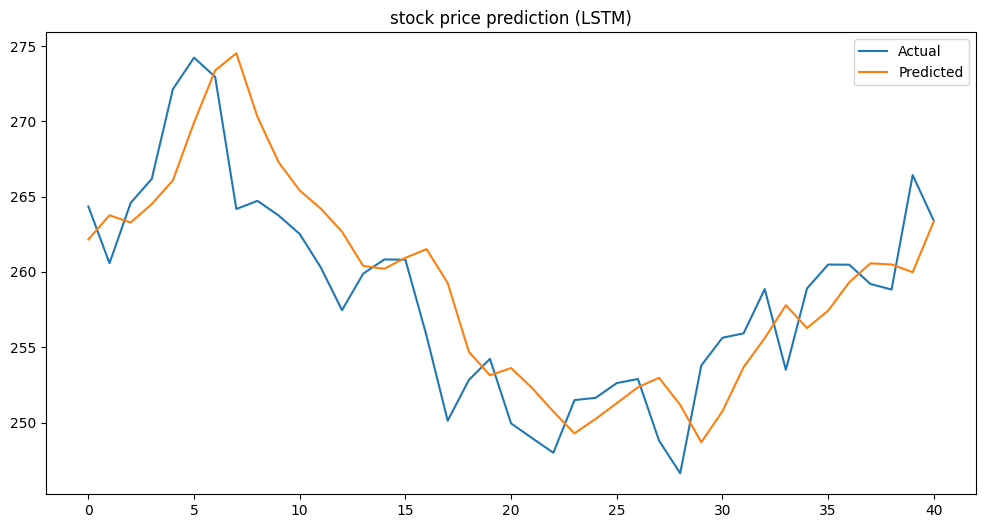

In [18]:
#1 Learning Rate(0.01)
import torch.optim as optim

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
for epoch in range(100):
  optimizer.zero_grad()
  y_pred = model(X_train_t)
  loss = loss_fn(y_pred, y_train_t)
  loss.backward()
  optimizer.step()

  if(epoch%10 == 0):
    print(f'Epoch {epoch}, Loss: {loss.item()}')

# eval modela and calculate predictions for testing data

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
  predictions = model(X_test_t).numpy()

# reshape for inverse transform

predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))
mae = mean_absolute_error(y_test_rescaled, predictions_rescaled)
# r2 = r2_score(y_test_rescaled, predictions_rescaled)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(predictions_rescaled, label='Predicted')
plt.legend()
plt.title("stock price prediction (LSTM)")
plt.show()

Epoch 0, Loss: 0.0018111373065039515
Epoch 10, Loss: 0.0606941320002079
Epoch 20, Loss: 0.04525172710418701
Epoch 30, Loss: 0.0371352881193161
Epoch 40, Loss: 0.03187423199415207
Epoch 50, Loss: 0.030073121190071106
Epoch 60, Loss: 0.02809906378388405
Epoch 70, Loss: 0.024722104892134666
Epoch 80, Loss: 0.02112664096057415
Epoch 90, Loss: 0.016063686460256577
RMSE: 17.339514797392965
MAE: 16.700440197456174


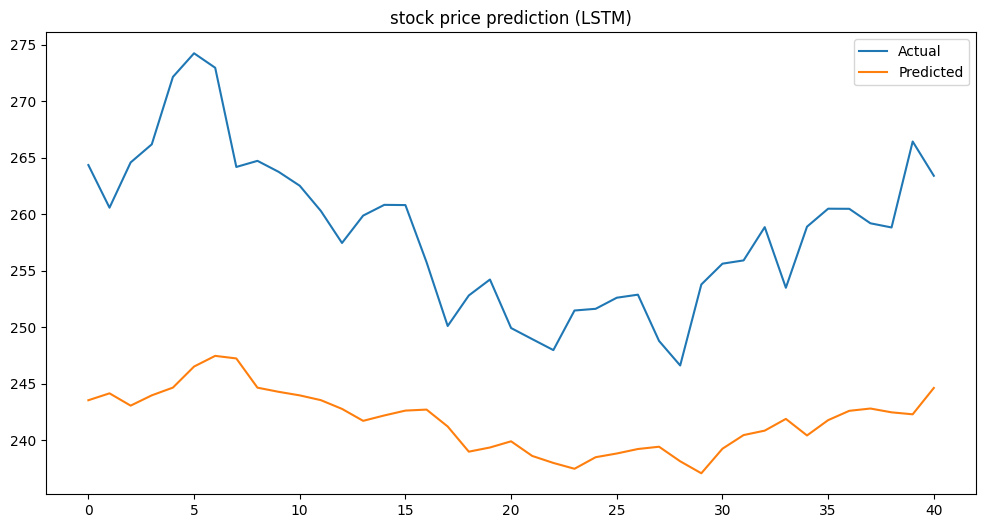

In [19]:
#1 Learning Rate(0.1)
import torch.optim as optim

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)
for epoch in range(100):
  optimizer.zero_grad()
  y_pred = model(X_train_t)
  loss = loss_fn(y_pred, y_train_t)
  loss.backward()
  optimizer.step()

  if(epoch%10 == 0):
    print(f'Epoch {epoch}, Loss: {loss.item()}')

# eval modela and calculate predictions for testing data

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
  predictions = model(X_test_t).numpy()

# reshape for inverse transform

predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))
mae = mean_absolute_error(y_test_rescaled, predictions_rescaled)
# r2 = r2_score(y_test_rescaled, predictions_rescaled)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(predictions_rescaled, label='Predicted')
plt.legend()
plt.title("stock price prediction (LSTM)")
plt.show()